## # Import necessary libraries

In [11]:

import numpy as np  
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt  
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix 
from imblearn.over_sampling import SMOTE  
from sklearn.linear_model import LogisticRegression  
from sklearn.neural_network import MLPClassifier 
from sklearn.svm import SVC  
from sklearn.ensemble import (
    RandomForestClassifier,  
    GradientBoostingClassifier,  
    AdaBoostClassifier,  
    ExtraTreesClassifier,
    StackingClassifier,  
    VotingClassifier 
)
from xgboost import XGBClassifier
import shap

In [12]:
import pandas as pd

# Read BRFSS 2023 XPT file
df = pd.read_sas(
    r"LLCP2023.XPT",
    format="xport",
    encoding="latin1"
)

print("Shape:", df.shape)

# Check the variables
print(df["_SMOKER3"].head())
print(df["_BMI5CAT"].head())
print(df["CVDINFR4"].head())
# Save as CSV
df.to_csv("BRFSS2023.csv", index=False)

print("CSV saved successfully.")

Shape: (433323, 350)
0    4.0
1    4.0
2    3.0
3    4.0
4    4.0
Name: _SMOKER3, dtype: float64
0    4.0
1    3.0
2    2.0
3    3.0
4    3.0
Name: _BMI5CAT, dtype: float64
0    2.0
1    2.0
2    2.0
3    2.0
4    2.0
Name: CVDINFR4, dtype: float64
CSV saved successfully.


In [13]:
from astropy.table import Table

table = Table.read("BRFSS2023.csv")

print(", ".join(table.colnames))
df.info()

_STATE, FMONTH, IDATE, IMONTH, IDAY, IYEAR, DISPCODE, SEQNO, _PSU, CTELENM1, PVTRESD1, COLGHOUS, STATERE1, CELPHON1, LADULT1, NUMADULT, RESPSLC1, LANDSEX2, LNDSXBRT, SAFETIME, CTELNUM1, CELLFON5, CADULT1, CELLSEX2, CELSXBRT, PVTRESD3, CCLGHOUS, CSTATE1, LANDLINE, HHADULT, SEXVAR, GENHLTH, PHYSHLTH, MENTHLTH, POORHLTH, PRIMINS1, PERSDOC3, MEDCOST1, CHECKUP1, EXERANY2, EXRACT12, EXEROFT1, EXERHMM1, EXRACT22, EXEROFT2, EXERHMM2, STRENGTH, BPHIGH6, BPMEDS1, CHOLCHK3, TOLDHI3, CHOLMED3, CVDINFR4, CVDCRHD4, CVDSTRK3, ASTHMA3, ASTHNOW, CHCSCNC1, CHCOCNC1, CHCCOPD3, ADDEPEV3, CHCKDNY2, HAVARTH4, DIABETE4, DIABAGE4, MARITAL, EDUCA, RENTHOM1, NUMHHOL4, NUMPHON4, CPDEMO1C, VETERAN3, EMPLOY1, CHILDREN, INCOME3, PREGNANT, WEIGHT2, HEIGHT3, DEAF, BLIND, DECIDE, DIFFWALK, DIFFDRES, DIFFALON, FALL12MN, FALLINJ5, SMOKE100, SMOKDAY2, USENOW3, ECIGNOW2, ALCDAY4, AVEDRNK3, DRNK3GE5, MAXDRNKS, FLUSHOT7, FLSHTMY3, PNEUVAC4, SHINGLE2, HIVTST7, HIVTSTD3, SEATBELT, DRNKDRI2, COVIDPO1, COVIDSM1, COVIDACT, PDIAB

In [14]:
selected_features = ['SEXVAR','GENHLTH','PHYSHLTH','MENTHLTH','CHECKUP1','EXERANY2','CVDINFR4','CVDSTRK3','ASTHMA3','CHCSCNC1',
    'CHCOCNC1','CHCCOPD3','ADDEPEV3','CHCKDNY2','HAVARTH4','DIABETE4','DEAF','BLIND','DECIDE','DIFFWALK','DIFFDRES','DIFFALON','PNEUVAC4','FLUSHOT7','HIVTST7',
    'COVIDPO1','_AGEG5YR','_RFHYPE6','_CHOLCH3','_BMI5CAT','_SMOKER3','DROCDY4_']
df_selected = df[selected_features]
print(df_selected.info())
df_selected.to_csv("BRFSS2023Data.csv", index=False)

<class 'pandas.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Data columns (total 32 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   SEXVAR    433323 non-null  float64
 1   GENHLTH   433319 non-null  float64
 2   PHYSHLTH  433320 non-null  float64
 3   MENTHLTH  433320 non-null  float64
 4   CHECKUP1  433321 non-null  float64
 5   EXERANY2  433321 non-null  float64
 6   CVDINFR4  433320 non-null  float64
 7   CVDSTRK3  433319 non-null  float64
 8   ASTHMA3   433320 non-null  float64
 9   CHCSCNC1  433320 non-null  float64
 10  CHCOCNC1  433320 non-null  float64
 11  CHCCOPD3  433320 non-null  float64
 12  ADDEPEV3  433320 non-null  float64
 13  CHCKDNY2  433320 non-null  float64
 14  HAVARTH4  433319 non-null  float64
 15  DIABETE4  433318 non-null  float64
 16  DEAF      420248 non-null  float64
 17  BLIND     419243 non-null  float64
 18  DECIDE    418184 non-null  float64
 19  DIFFWALK  417177 non-null  float64
 20  DIFFDRES  41645

In [16]:
df1= pd.read_csv("BRFSS2023Data.csv")

## Remove the duplicate

Duplicates negatively impact model performance by introducing bias, increasing overfitting, and skewing results.

In [17]:
print(df1['CVDINFR4'].value_counts())
print(f"Number of unique values: {df1['CVDINFR4'].nunique()}")
print(f"Unique values: {df1['CVDINFR4'].unique()}")

CVDINFR4
2.0    407304
1.0     23451
7.0      2314
9.0       251
Name: count, dtype: int64
Number of unique values: 4
Unique values: [ 2.  1.  7.  9. nan]


In [18]:
num_duplicates = df1.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)
data_clean = df1.drop_duplicates()
print("After removing duplicates:", data_clean.shape)
data_clean.to_csv("brfssdataclean.csv", index=False)

Number of duplicate rows: 18335
After removing duplicates: (414988, 32)


In [19]:
df2=pd.read_csv("brfssdataclean.csv")
print(df2['CVDINFR4'].value_counts())
print(f"Number of unique values: {df2['CVDINFR4'].nunique()}")
print(f"Unique values: {df2['CVDINFR4'].unique()}")

CVDINFR4
2.0    389032
1.0     23398
7.0      2311
9.0       244
Name: count, dtype: int64
Number of unique values: 4
Unique values: [ 2.  1.  7.  9. nan]


## Loading Dataset and Mapping the features from the codebook

In [20]:
print(df2.columns.tolist())

['SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'CHECKUP1', 'EXERANY2', 'CVDINFR4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'PNEUVAC4', 'FLUSHOT7', 'HIVTST7', 'COVIDPO1', '_AGEG5YR', '_RFHYPE6', '_CHOLCH3', '_BMI5CAT', '_SMOKER3', 'DROCDY4_']


In [21]:
missing_counts = df2.isnull().sum()
print(missing_counts.sort_values(ascending=False))

_BMI5CAT    37079
COVIDPO1    28836
HIVTST7     26438
PNEUVAC4    25576
FLUSHOT7    24577
DIFFALON    15042
DIFFDRES    14069
DIFFWALK    13360
DECIDE      12394
BLIND       11349
DEAF        10373
DIABETE4        5
HAVARTH4        4
GENHLTH         4
CVDSTRK3        4
CVDINFR4        3
PHYSHLTH        3
MENTHLTH        3
ASTHMA3         3
ADDEPEV3        3
CHCSCNC1        3
CHCKDNY2        3
CHCOCNC1        3
CHCCOPD3        3
EXERANY2        2
CHECKUP1        2
SEXVAR          0
_AGEG5YR        0
_RFHYPE6        0
_CHOLCH3        0
_SMOKER3        0
DROCDY4_        0
dtype: int64


In [22]:
import numpy as np

df2_clean = df2.copy()

# Replace with NaN for all columns
special_codes_all = [7, 9, 77, 88, 99, 777, 888, 999, 900]

# Replace with NaN for AgeGroup only
special_codes_age = [14, 77, 88, 99, 777, 888, 999, 900]

target_column = "CVDINFR4"
age_column = "_AGEG5YR"

for col in df2_clean.columns:

    if col == age_column:
        # Keep 7 and 9; replace 14 and other special codes
        df2_clean[col] = df2_clean[col].replace(special_codes_age, np.nan)

    else:
        # Replace all special codes
        df2_clean[col] = df2_clean[col].replace(special_codes_all, np.nan)

print("Cleaning completed.")

df2_clean.to_csv("BRFSS.csv", index=False)

Cleaning completed.


In [23]:
df3=pd.read_csv('BRFSS.csv')

In [24]:
print(df3["_AGEG5YR"].unique())

[13. 12.  9.  8. 10. 11.  6.  4.  5.  7.  2.  1. nan  3.]


In [25]:
missing_counts = df3.isnull().sum()
print(missing_counts.sort_values(ascending=False))

PHYSHLTH    258440
MENTHLTH    255308
PNEUVAC4     59420
DROCDY4_     51206
HIVTST7      47071
_BMI5CAT     37079
COVIDPO1     30905
FLUSHOT7     28129
_CHOLCH3     26102
_SMOKER3     20164
DIFFALON     16576
DECIDE       15376
DIFFWALK     15057
DIFFDRES     14870
BLIND        12972
DEAF         12083
_AGEG5YR      7469
CHECKUP1      5745
CHCSCNC1      2921
ADDEPEV3      2580
CVDINFR4      2558
HAVARTH4      2553
CHCOCNC1      2330
CHCCOPD3      2059
_RFHYPE6      1910
CHCKDNY2      1884
ASTHMA3       1693
CVDSTRK3      1467
GENHLTH       1256
EXERANY2      1245
DIABETE4       977
SEXVAR           0
dtype: int64


In [26]:
import numpy as np

df3["DROCDY4_"] = (
    df3["DROCDY4_"]
    .replace(5.397605346934028e-79, 0)
)

In [27]:
import pandas as pd

# ======================================================
# Rename columns
# ======================================================

col_map = {
    "SEXVAR": "Sex",
    "GENHLTH": "GeneralHealth",
    "PHYSHLTH": "PhysicalHealthDays",
    "MENTHLTH": "MentalHealthDays",
    "CHECKUP1": "LastCheckupTime",
    "EXERANY2": "PhysicalActivity",
    "CVDINFR4": "HadHeartAttack",
    "CVDSTRK3": "HadStroke",
    "ASTHMA3": "HadAsthma",
    "CHCSCNC1": "HadSkinCancer",
    "CHCOCNC1": "HadOtherCancer",
    "CHCCOPD3": "HadCOPD",
    "ADDEPEV3": "HadDepressiveDisorder",
    "CHCKDNY2": "HadKidneyDisease",
    "HAVARTH4": "HadArthritis",
    "DIABETE4": "HadDiabetes",
    "DEAF": "DifficultyHearing",
    "BLIND": "DifficultySeeing",
    "DECIDE": "DifficultyMakingDecisions",
    "DIFFWALK": "DifficultyWalking",
    "DIFFDRES": "DifficultyDressing",
    "DIFFALON": "DifficultyErrands",
    "PNEUVAC4": "EverHadPneumoniaVax",
    "FLUSHOT7": "ReceivedFluVax",
    "HIVTST7": "EverTestedHIV",
    "COVIDPO1": "EverHadCOVID",
    "_AGEG5YR": "AgeGroup",
    "_RFHYPE6": "HighBloodPressureRisk",
    "_CHOLCH3": "CholesterolChecked",
    "_BMI5CAT": "BMICategory",
    "_SMOKER3": "SmokingStatus",
    "DROCDY4_": "DrinksPerDay"
}

# ======================================================
# Value mappings
# ======================================================

value_mappings = {

    "Sex": {1: "Male", 2: "Female"},

    "GeneralHealth": {
        1: "Excellent",
        2: "Very good",
        3: "Good",
        4: "Fair",
        5: "Poor"
    },

    "LastCheckupTime": {
        1: "Within past year",
        2: "Within past 2 years",
        3: "Within past 5 years",
        4: "5 or more years ago",
        8: "Never"
    },

    "PhysicalActivity": {1: "Yes", 2: "No"},

    "HadHeartAttack": {1: "Yes", 2: "No"},
    "HadStroke": {1: "Yes", 2: "No"},
    "HadAsthma": {1: "Yes", 2: "No"},
    "HadSkinCancer": {1: "Yes", 2: "No"},
    "HadOtherCancer": {1: "Yes", 2: "No"},
    "HadCOPD": {1: "Yes", 2: "No"},
    "HadDepressiveDisorder": {1: "Yes", 2: "No"},
    "HadKidneyDisease": {1: "Yes", 2: "No"},
    "HadArthritis": {1: "Yes", 2: "No"},

    "HadDiabetes": {
        1: "Yes",
        2: "Gestational diabetes",
        3: "No",
        4: "Prediabetes"
    },

    "DifficultyHearing": {1: "Yes", 2: "No"},
    "DifficultySeeing": {1: "Yes", 2: "No"},
    "DifficultyMakingDecisions": {1: "Yes", 2: "No"},
    "DifficultyWalking": {1: "Yes", 2: "No"},
    "DifficultyDressing": {1: "Yes", 2: "No"},
    "DifficultyErrands": {1: "Yes", 2: "No"},

    "EverHadPneumoniaVax": {1: "Yes", 2: "No"},
    "ReceivedFluVax": {1: "Yes", 2: "No"},
    "EverTestedHIV": {1: "Yes", 2: "No"},
    "EverHadCOVID": {1: "Yes", 2: "No"},

    "AgeGroup": {
        1: "18-24",
        2: "25-29",
        3: "30-34",
        4: "35-39",
        5: "40-44",
        6: "45-49",
        7: "50-54",
        8: "55-59",
        9: "60-64",
        10: "65-69",
        11: "70-74",
        12: "75-79",
        13: "80+",
    },

    "HighBloodPressureRisk": {
        1: "Yes",
        2: "No"
    },

    "CholesterolChecked": {
        1: "Yes",
        2: "No",
        3: "Never had cholesterol checked"
    },

    "BMICategory": {
        1: "Underweight",
        2: "Normal",
        3: "Overweight",
        4: "Obese"
    },

    "SmokingStatus": {
        1: "Current smoker - daily",
        2: "Current smoker - some days",
        3: "Former smoker",
        4: "Never smoked"
    }
}
df3 = df3.rename(columns=col_map)


# Apply value mappings
for col, mapping in value_mappings.items():
    if col in df3.columns:
        df3[col] = df3[col].replace(mapping)
df3.to_csv("BRFSS_Mapped_Dataset.csv", index=False)

print("Dataset saved successfully.")
# Check results
df3.head()


Dataset saved successfully.


,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivity,HadHeartAttack,HadStroke,HadAsthma,HadSkinCancer,...,EverHadPneumoniaVax,ReceivedFluVax,EverTestedHIV,EverHadCOVID,AgeGroup,HighBloodPressureRisk,CholesterolChecked,BMICategory,SmokingStatus,DrinksPerDay
0,Female,Very good,NaN,NaN,Within past 2 years,No,No,No,No,No,...,No,No,No,No,80+,No,Yes,Obese,Never smoked,0.0
1,Female,Very good,NaN,NaN,Within past 2 years,Yes,No,No,No,No,...,Yes,Yes,No,No,80+,No,Yes,Overweight,Never smoked,0.0
2,Female,Fair,6.0,2.0,Within past year,Yes,No,No,Yes,No,...,Yes,Yes,No,No,80+,No,Yes,Normal,Former smoker,0.0
3,Female,Very good,2.0,NaN,Within past 5 years,Yes,No,No,No,Yes,...,Yes,Yes,Yes,No,75-79,Yes,Yes,Overweight,Never smoked,0.0
4,Female,Fair,NaN,NaN,Within past year,Yes,No,No,No,No,...,Yes,No,No,No,75-79,No,Yes,Overweight,Never smoked,NaN


In [28]:
df4=pd.read_csv("BRFSS_Mapped_Dataset.csv")

In [29]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 414988 entries, 0 to 414987
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        414988 non-null  str    
 1   GeneralHealth              413732 non-null  str    
 2   PhysicalHealthDays         156548 non-null  float64
 3   MentalHealthDays           159680 non-null  float64
 4   LastCheckupTime            409243 non-null  str    
 5   PhysicalActivity           413743 non-null  str    
 6   HadHeartAttack             412430 non-null  str    
 7   HadStroke                  413521 non-null  str    
 8   HadAsthma                  413295 non-null  str    
 9   HadSkinCancer              412067 non-null  str    
 10  HadOtherCancer             412658 non-null  str    
 11  HadCOPD                    412929 non-null  str    
 12  HadDepressiveDisorder      412408 non-null  str    
 13  HadKidneyDisease           413104 non-nu

In [30]:
print("Dataset shape:", df4.shape)

print("\nHadHeartAttack distribution (including NaN):")
print(df4['HadHeartAttack'].value_counts(dropna=False).sort_index())

Dataset shape: (414988, 32)

HadHeartAttack distribution (including NaN):
HadHeartAttack
No     389032
Yes     23398
NaN      2558
Name: count, dtype: int64


Dataset shape: (412430, 32)
\HadHeartAttack distribution:
HadHeartAttack
No     389032
Yes     23398
Name: count, dtype: int64


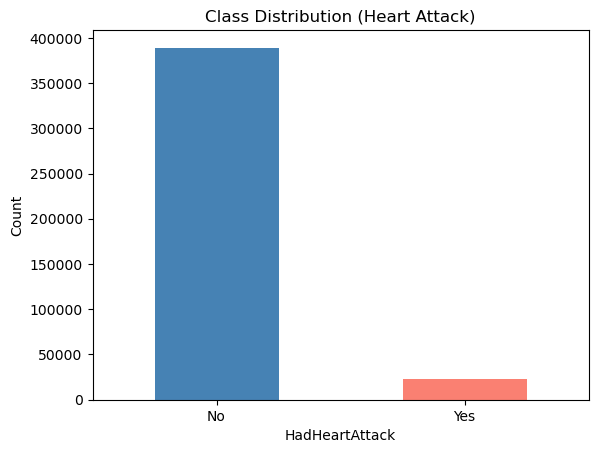


Cleaned dataset saved as 'BRFSS2023_Cleaned.csv'


In [31]:
import matplotlib.pyplot as plt

# ======================================================
# Keep only Yes and No
# ======================================================

df4 = df4[df4["HadHeartAttack"].isin(["Yes", "No"])].copy()

# ======================================================
# Check dataset
# ======================================================

print("Dataset shape:", df4.shape)

print("\HadHeartAttack distribution:")
print(df4["HadHeartAttack"].value_counts())

# ======================================================
# Plot class distribution
# ======================================================

df4["HadHeartAttack"].value_counts().plot(
    kind="bar",
    color=["steelblue", "salmon"]
)

plt.title("Class Distribution (Heart Attack)")
plt.xlabel("HadHeartAttack")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ======================================================
# Save cleaned dataset
# ======================================================

df4.to_csv("BRFSS2023_Cleaned.csv", index=False)

print("\nCleaned dataset saved as 'BRFSS2023_Cleaned.csv'")

In [32]:
df5=pd.read_csv("BRFSS2023_Cleaned.csv")

In [33]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 412430 entries, 0 to 412429
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        412430 non-null  str    
 1   GeneralHealth              411237 non-null  str    
 2   PhysicalHealthDays         155381 non-null  float64
 3   MentalHealthDays           158755 non-null  float64
 4   LastCheckupTime            406832 non-null  str    
 5   PhysicalActivity           411264 non-null  str    
 6   HadHeartAttack             412430 non-null  str    
 7   HadStroke                  411356 non-null  str    
 8   HadAsthma                  411009 non-null  str    
 9   HadSkinCancer              409825 non-null  str    
 10  HadOtherCancer             410382 non-null  str    
 11  HadCOPD                    410689 non-null  str    
 12  HadDepressiveDisorder      410136 non-null  str    
 13  HadKidneyDisease           410822 non-nu

In [34]:
import pandas as pd

# Numerical feature names
numerical_features = [
    "PhysicalHealthDays",
    "MentalHealthDays",
    "DrinksPerDay"
]

print("=" * 70)
print("NUMERICAL FEATURES BEFORE PREPROCESSING")
print("=" * 70)

summary = []

for col in numerical_features:
    print(f"\n{col}")
    print("-" * 50)

    summary.append({
        "Variable": col,
        "Minimum": df5[col].min(),
        "Maximum": df5[col].max(),
        "Unique Values": df5[col].nunique()
    })

summary_df5 = pd.DataFrame(summary)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(summary_df5)

NUMERICAL FEATURES BEFORE PREPROCESSING

PhysicalHealthDays
--------------------------------------------------

MentalHealthDays
--------------------------------------------------

DrinksPerDay
--------------------------------------------------

SUMMARY
             Variable  Minimum  Maximum  Unique Values
0  PhysicalHealthDays      1.0     30.0             28
1    MentalHealthDays      1.0     30.0             28
2        DrinksPerDay      0.0    100.0             33
